In [2]:
import torch
import matplotlib.pyplot as plt

In [5]:
# Apple (mps) GPU 

device = "mps" if torch.backends.mps.is_available() else "cpu"

'mps'

In [124]:
## Linear Regression class

class LinearRegression(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.weights = torch.nn.Parameter(torch.rand(1,
                                                     dtype=torch.float,
                                                     requires_grad=True,
                                                    device = device))

        self.bias = torch.nn.Parameter(torch.rand(1,
                                                  dtype=torch.float,
                                                  requires_grad=True,
                                                 device = device))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.bias + self.weights * x

In [125]:
weight = 0.7
bias = 0.3

torch.manual_seed(42)

X = torch.arange(0, 10, 0.1, device = device)
y = bias + weight * X

split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [132]:
model = LinearRegression()

array([0.        , 0.1       , 0.2       , 0.3       , 0.4       ,
       0.5       , 0.6       , 0.7       , 0.8       , 0.90000004,
       1.        , 1.1       , 1.2       , 1.3000001 , 1.4       ,
       1.5       , 1.6       , 1.7       , 1.8000001 , 1.9       ,
       2.        , 2.1000001 , 2.2       , 2.3       , 2.4       ,
       2.5       , 2.6000001 , 2.7       , 2.8       , 2.9       ,
       3.        , 3.1000001 , 3.2       , 3.3       , 3.4       ,
       3.5       , 3.6000001 , 3.7       , 3.8       , 3.9       ,
       4.        , 4.1       , 4.2000003 , 4.3       , 4.4       ,
       4.5       , 4.6       , 4.7000003 , 4.8       , 4.9       ,
       5.        , 5.1       , 5.2000003 , 5.3       , 5.4       ,
       5.5       , 5.6       , 5.7000003 , 5.8       , 5.9       ,
       6.        , 6.1       , 6.2000003 , 6.3       , 6.4       ,
       6.5       , 6.6       , 6.7000003 , 6.8       , 6.9       ,
       7.        , 7.1       , 7.2000003 , 7.3       , 7.4    

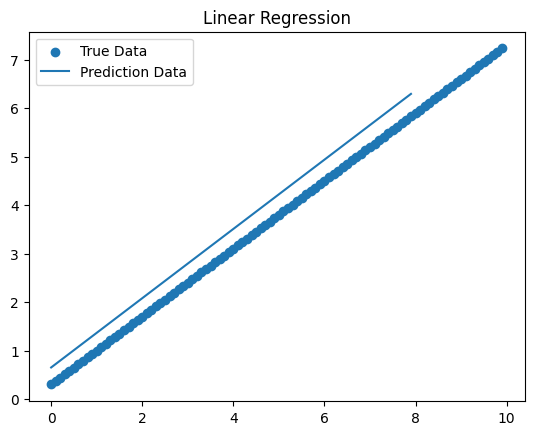

In [138]:
with torch.inference_mode():
    y_pred = model(X_train)

plt.scatter(X.cpu(), y.cpu(), label="True Data")
plt.plot(X_train.cpu(), y_pred.cpu(), label="Prediction Data")
plt.legend()
plt.title("Linear Regression")
plt.show()

In [139]:
epochs = 100
epoch_count = []
losses = []
test_losses = []

torch.manual_seed(42)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

for epoch in range(epochs):
    model.train()

    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    model.eval()

    with torch.inference_mode():
        test_y_pred = model(X_test)
        test_loss = loss_fn(test_y_pred, y_test)
        test_losses.append(test_loss.item())
        
    epoch_count.append(epoch)

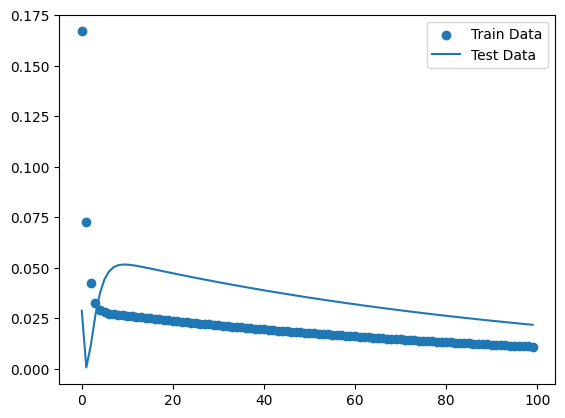

In [140]:
plt.scatter(epoch_count, losses, label = "Train Data")
plt.plot(epoch_count, test_losses, label = "Test Data")
plt.legend()
plt.show()

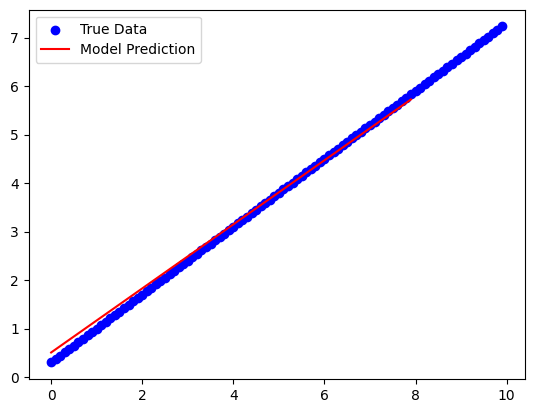

In [141]:
plt.scatter(X.cpu(), y.cpu(), label = "True Data", color = "blue")
plt.plot(X_train.cpu(), y_pred.cpu().detach().numpy(), label = "Model Prediction", color = "red")
plt.legend()
plt.show()